In [1]:
import os
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import models, transforms

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [3]:
classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

num_classes = len(classes)

print("Classes:", classes)
print("Number of classes:", num_classes)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


In [4]:
model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    num_classes
)

model = model.to(device)

print("ResNet18 model created successfully!")

ResNet18 model created successfully!


In [5]:
MODEL_PATH = "best_resnet18_neu_det.pth"

print("Model path:", MODEL_PATH)
print("Model exists:", os.path.exists(MODEL_PATH))

Model path: best_resnet18_neu_det.pth
Model exists: True


In [14]:
import os

DATASET_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET"

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET
Dataset exists: True


In [6]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Trained model loaded successfully!")

Trained model loaded successfully!


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing ready!")

Image preprocessing ready!


In [8]:
image_path = os.path.join(
    "..",
    "archive",
    "NEU-DET",
    "validation",
    "images",
    "scratches",
    "scratches_241.jpg"
)

print("Image path:", image_path)
print("Image exists:", os.path.exists(image_path))

Image path: ..\archive\NEU-DET\validation\images\scratches\scratches_241.jpg
Image exists: True


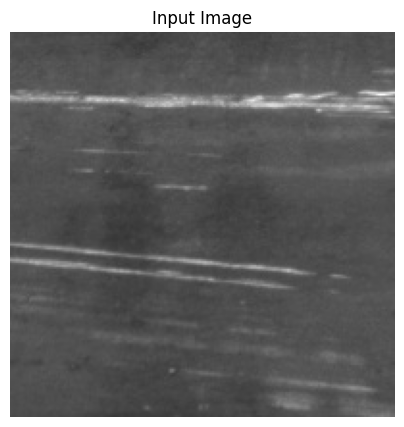

In [9]:
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

In [10]:
image_tensor = transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

with torch.no_grad():
    outputs = model(image_tensor)

probabilities = torch.softmax(outputs, dim=1)

confidence, predicted_class = torch.max(
    probabilities,
    dim=1
)

predicted_label = classes[predicted_class.item()]

confidence_value = confidence.item() * 100

print("Prediction completed!")
print()
print("Predicted Defect :", predicted_label)
print("Confidence       :", f"{confidence_value:.2f}%")

Prediction completed!

Predicted Defect : scratches
Confidence       : 99.99%


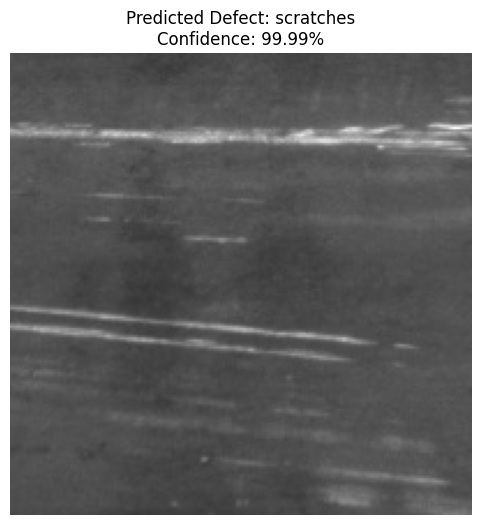

In [11]:
plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"Predicted Defect: {predicted_label}\n"
    f"Confidence: {confidence_value:.2f}%"
)

plt.axis("off")
plt.show()

In [12]:
print("Class Probabilities")
print("-" * 30)

for class_name, probability in zip(
    classes,
    probabilities[0]
):
    print(
        f"{class_name:20s}: "
        f"{probability.item() * 100:.2f}%"
    )

Class Probabilities
------------------------------
crazing             : 0.00%
inclusion           : 0.00%
patches             : 0.00%
pitted_surface      : 0.00%
rolled-in_scale     : 0.00%
scratches           : 99.99%


In [15]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Test images from validation dataset
validation_path = os.path.join(
    DATASET_PATH,
    "validation",
    "images"
)

results = []

print("Testing all 6 defect classes...")
print("=" * 60)

for class_name in classes:

    class_path = os.path.join(validation_path, class_name)

    # Get image files
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Select first image
    image_name = sorted(image_files)[0]
    image_path = os.path.join(class_path, image_name)

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

        predicted_index = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_index].item()

    predicted_class = classes[predicted_index]

    correct = class_name == predicted_class

    results.append({
        "actual": class_name,
        "predicted": predicted_class,
        "confidence": confidence,
        "correct": correct,
        "image": image
    })

    print(f"Actual     : {class_name}")
    print(f"Predicted  : {predicted_class}")
    print(f"Confidence : {confidence * 100:.2f}%")
    print(f"Result     : {'CORRECT' if correct else 'WRONG'}")
    print("-" * 60)

Testing all 6 defect classes...
Actual     : crazing
Predicted  : crazing
Confidence : 99.99%
Result     : CORRECT
------------------------------------------------------------
Actual     : inclusion
Predicted  : inclusion
Confidence : 99.99%
Result     : CORRECT
------------------------------------------------------------
Actual     : patches
Predicted  : patches
Confidence : 99.93%
Result     : CORRECT
------------------------------------------------------------
Actual     : pitted_surface
Predicted  : pitted_surface
Confidence : 100.00%
Result     : CORRECT
------------------------------------------------------------
Actual     : rolled-in_scale
Predicted  : rolled-in_scale
Confidence : 99.93%
Result     : CORRECT
------------------------------------------------------------
Actual     : scratches
Predicted  : scratches
Confidence : 99.99%
Result     : CORRECT
------------------------------------------------------------


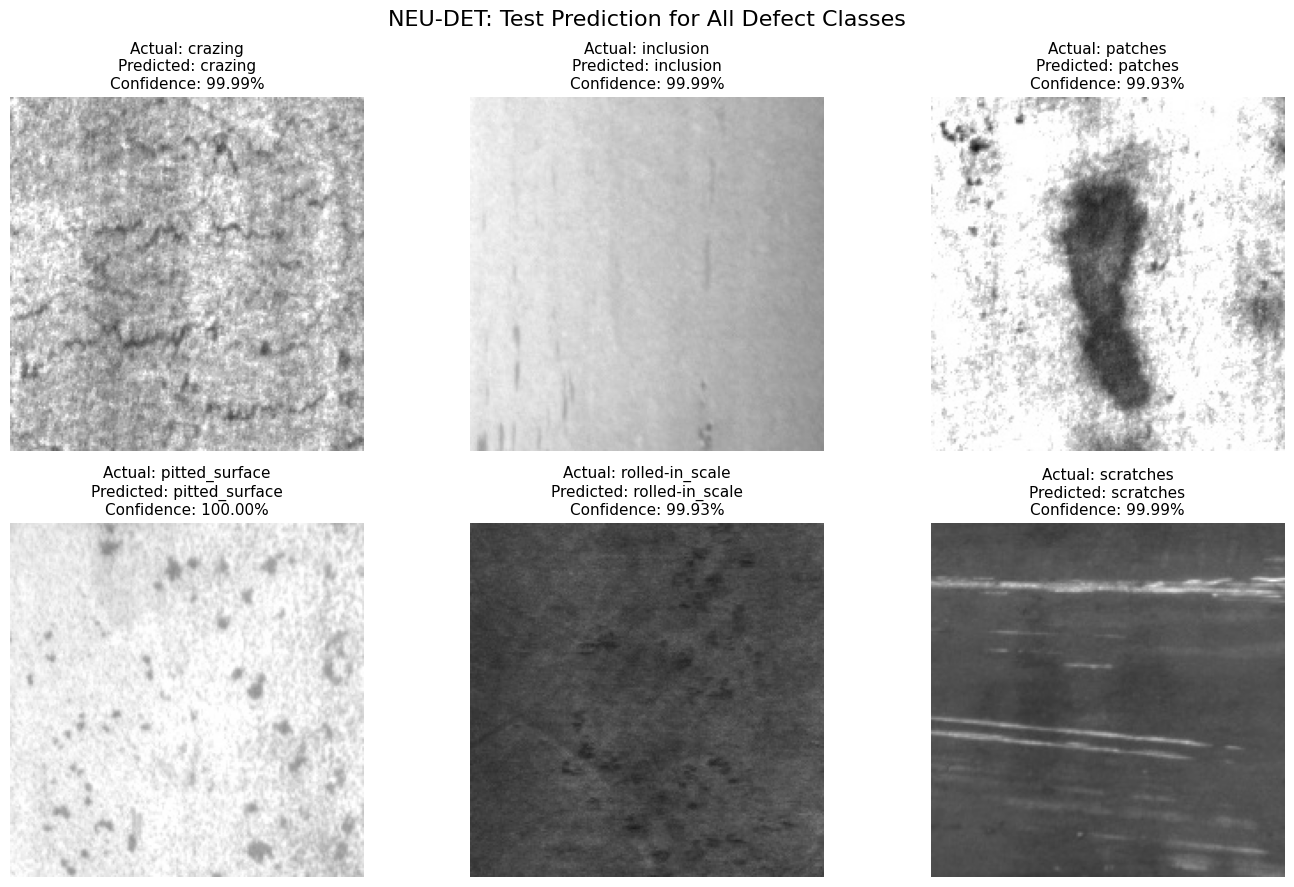

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, result in zip(axes.flat, results):

    ax.imshow(result["image"])

    ax.set_title(
        f"Actual: {result['actual']}\n"
        f"Predicted: {result['predicted']}\n"
        f"Confidence: {result['confidence'] * 100:.2f}%",
        fontsize=11
    )

    ax.axis("off")

plt.suptitle(
    "NEU-DET: Test Prediction for All Defect Classes",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [17]:
correct_predictions = sum(
    result["correct"] for result in results
)

total_predictions = len(results)

test_accuracy = correct_predictions / total_predictions

print("=" * 60)
print("DAY 9 TEST SUMMARY")
print("=" * 60)

print(f"Total classes tested : {total_predictions}")
print(f"Correct predictions  : {correct_predictions}")
print(f"Wrong predictions    : {total_predictions - correct_predictions}")
print(f"Test accuracy        : {test_accuracy * 100:.2f}%")
print("=" * 60)

DAY 9 TEST SUMMARY
Total classes tested : 6
Correct predictions  : 6
Wrong predictions    : 0
Test accuracy        : 100.00%


In [18]:
print("=" * 60)
print("DAY 10 - FINAL MODEL PERFORMANCE")
print("=" * 60)

print(f"Validation Accuracy     : 100.00%")
print(f"Noise Robustness        : 99.44%")
print(f"Inference Test Accuracy : {test_accuracy * 100:.2f}%")

print("-" * 60)
print("Number of Defect Classes: 6")
print("Model                   : ResNet18")
print("=" * 60)

DAY 10 - FINAL MODEL PERFORMANCE
Validation Accuracy     : 100.00%
Noise Robustness        : 99.44%
Inference Test Accuracy : 100.00%
------------------------------------------------------------
Number of Defect Classes: 6
Model                   : ResNet18


In [19]:
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

for result in results:
    actual = result["actual"]
    class_total[actual] += 1

    if result["correct"]:
        class_correct[actual] += 1

print("=" * 60)
print("PER-CLASS INFERENCE PERFORMANCE")
print("=" * 60)

for class_name in classes:
    correct = class_correct[class_name]
    total = class_total[class_name]

    accuracy = (correct / total) * 100 if total > 0 else 0

    print(f"{class_name:20s}: {accuracy:.2f}% "
          f"({correct}/{total})")

print("=" * 60)

PER-CLASS INFERENCE PERFORMANCE
crazing             : 100.00% (1/1)
inclusion           : 100.00% (1/1)
patches             : 100.00% (1/1)
pitted_surface      : 100.00% (1/1)
rolled-in_scale     : 100.00% (1/1)
scratches           : 100.00% (1/1)


In [21]:
import numpy as np

# Get confidence values from inference results
confidence_array = np.array([
    result["confidence"] for result in results
])

print("=" * 60)
print("MODEL CONFIDENCE ANALYSIS")
print("=" * 60)

print(f"Average Confidence : {confidence_array.mean() * 100:.2f}%")
print(f"Minimum Confidence : {confidence_array.min() * 100:.2f}%")
print(f"Maximum Confidence : {confidence_array.max() * 100:.2f}%")

print("-" * 60)

high_confidence = np.sum(confidence_array >= 0.90)

medium_confidence = np.sum(
    (confidence_array >= 0.70) &
    (confidence_array < 0.90)
)

low_confidence = np.sum(confidence_array < 0.70)

print(f"High Confidence (>=90%) : {high_confidence}")
print(f"Medium Confidence       : {medium_confidence}")
print(f"Low Confidence (<70%)   : {low_confidence}")

print("=" * 60)

MODEL CONFIDENCE ANALYSIS
Average Confidence : 99.97%
Minimum Confidence : 99.93%
Maximum Confidence : 100.00%
------------------------------------------------------------
High Confidence (>=90%) : 6
Medium Confidence       : 0
Low Confidence (<70%)   : 0


In [22]:
sorted_results = sorted(
    results,
    key=lambda x: x["confidence"]
)

print("=" * 60)
print("LOWEST CONFIDENCE PREDICTIONS")
print("=" * 60)

for result in sorted_results[:5]:

    print(f"Actual     : {result['actual']}")
    print(f"Predicted  : {result['predicted']}")
    print(f"Confidence : {result['confidence'] * 100:.2f}%")
    print(f"Result     : {'CORRECT' if result['correct'] else 'WRONG'}")
    print("-" * 60)

LOWEST CONFIDENCE PREDICTIONS
Actual     : patches
Predicted  : patches
Confidence : 99.93%
Result     : CORRECT
------------------------------------------------------------
Actual     : rolled-in_scale
Predicted  : rolled-in_scale
Confidence : 99.93%
Result     : CORRECT
------------------------------------------------------------
Actual     : crazing
Predicted  : crazing
Confidence : 99.99%
Result     : CORRECT
------------------------------------------------------------
Actual     : inclusion
Predicted  : inclusion
Confidence : 99.99%
Result     : CORRECT
------------------------------------------------------------
Actual     : scratches
Predicted  : scratches
Confidence : 99.99%
Result     : CORRECT
------------------------------------------------------------


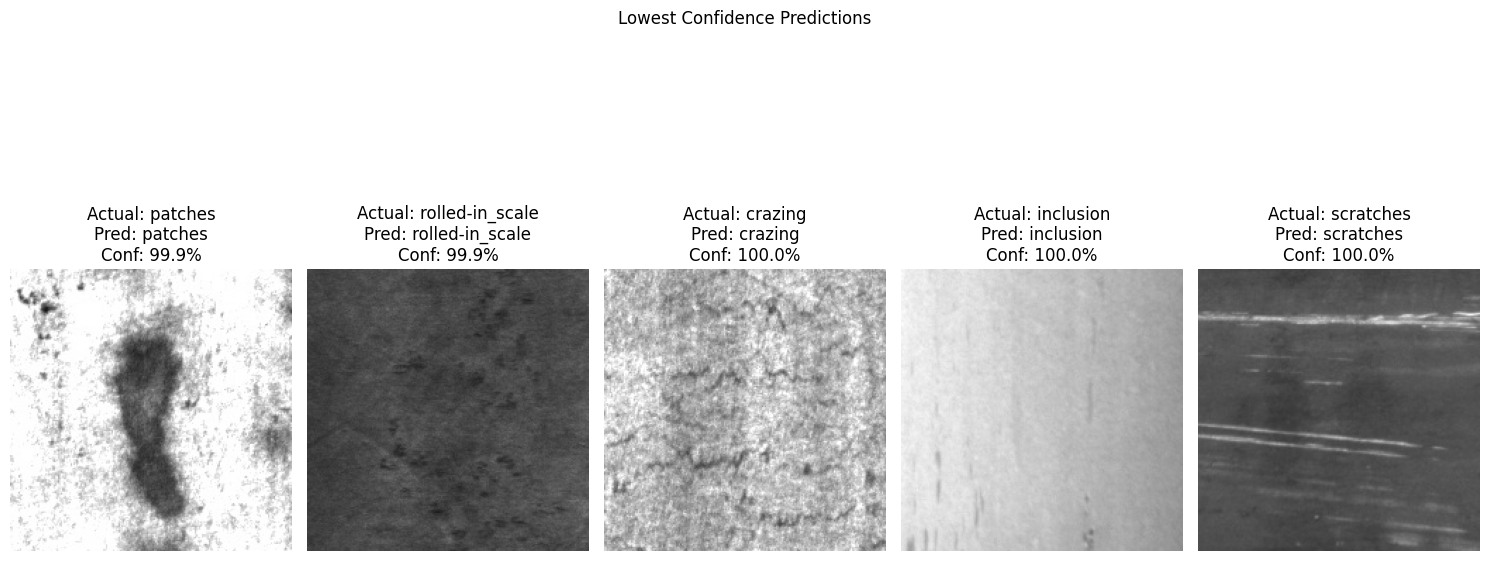

In [23]:
import matplotlib.pyplot as plt

lowest_confidence = sorted_results[:5]

plt.figure(figsize=(15, 8))

for i, result in enumerate(lowest_confidence):

    plt.subplot(1, 5, i + 1)

    plt.imshow(result["image"])

    plt.title(
        f"Actual: {result['actual']}\n"
        f"Pred: {result['predicted']}\n"
        f"Conf: {result['confidence'] * 100:.1f}%"
    )

    plt.axis("off")

plt.suptitle("Lowest Confidence Predictions")
plt.tight_layout()
plt.show()

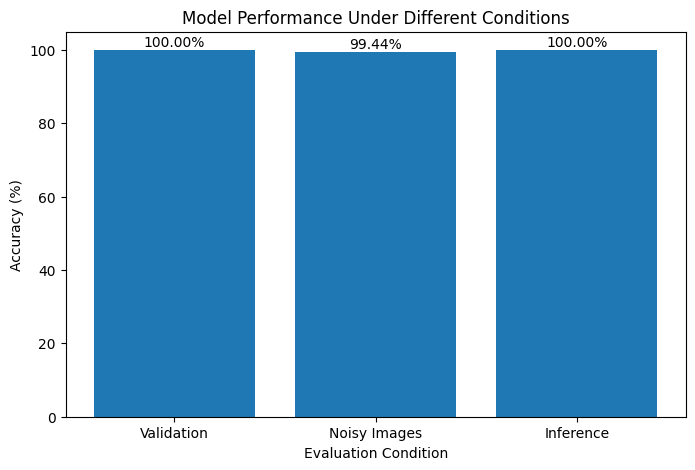

In [24]:
import matplotlib.pyplot as plt

evaluation_names = [
    "Validation",
    "Noisy Images",
    "Inference"
]

evaluation_accuracy = [
    100.00,
    99.44,
    test_accuracy * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    evaluation_names,
    evaluation_accuracy
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Evaluation Condition")
plt.title("Model Performance Under Different Conditions")

plt.ylim(0, 105)

for bar, value in zip(bars, evaluation_accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [26]:
validation_accuracy = 1.00
noise_accuracy = 0.9944

accuracy_drop = (
    validation_accuracy - noise_accuracy
) * 100

print("=" * 60)
print("ROBUSTNESS ANALYSIS")
print("=" * 60)

print(f"Normal Validation Accuracy : {validation_accuracy * 100:.2f}%")
print(f"Noisy Image Accuracy       : {noise_accuracy * 100:.2f}%")
print(f"Accuracy Drop              : {accuracy_drop:.2f}%")

if accuracy_drop < 1:
    print("Robustness Assessment      : Excellent")
elif accuracy_drop < 5:
    print("Robustness Assessment      : Good")
else:
    print("Robustness Assessment      : Needs Improvement")

print("=" * 60)

ROBUSTNESS ANALYSIS
Normal Validation Accuracy : 100.00%
Noisy Image Accuracy       : 99.44%
Accuracy Drop              : 0.56%
Robustness Assessment      : Excellent
